# ov.fm — Unified Foundation Model API

The `ov.fm` module provides a **unified, model-agnostic API** for working with 22 single-cell foundation models. Instead of learning each model's unique interface, you can use the same 6-step workflow for any model:

1. **Discover** — Browse available models and their capabilities
2. **Profile** — Automatically analyze your dataset
3. **Select** — Let the system recommend the best model
4. **Validate** — Check data-model compatibility before running
5. **Run** — Execute inference with a single function call
6. **Interpret** — Generate QA metrics and visualizations

**Supported models include:** scGPT, Geneformer, UCE, scFoundation, CellPLM, scBERT, GeneCompass, Nicheformer, scMulan, and 13 more.

**Cite:** Zeng, Z. et al. (2024). OmicVerse: a framework for bridging and deepening insights across bulk and single-cell sequencing. *Nature Communications*, 15(1), 5983.

In [1]:
import omicverse as ov
import scanpy as sc
import numpy as np
import warnings
warnings.filterwarnings('ignore')

sc.settings.set_figure_params(dpi=80, facecolor='white')
sc.settings.figdir = './figures/'

## Step 1: Discover Available Models

Use `ov.fm.list_models()` to browse all registered foundation models. You can filter by task type to find models that support your specific analysis.

In [2]:
# List all available models
all_models = ov.fm.list_models()
print(f"Total models available: {all_models['count']}")

# Display as a table
import pandas as pd
df = pd.DataFrame(all_models['models'])
df[['name', 'status', 'tasks', 'species', 'zero_shot', 'gpu_required', 'min_vram_gb']]

Total models available: 22


,name,status,tasks,species,zero_shot,gpu_required,min_vram_gb
0,scgpt,ready,"[embed, integrate]","[human, mouse]",True,True,8
1,geneformer,ready,"[embed, integrate]",[human],True,False,4
2,uce,ready,"[embed, integrate]","[human, mouse, zebrafish, mouse_lemur, macaque...",True,True,16
3,scfoundation,ready,"[embed, integrate]",[human],True,True,16
4,scbert,partial,"[embed, integrate]",[human],True,True,8
5,genecompass,partial,"[embed, integrate]","[human, mouse]",True,True,16
6,cellplm,ready,"[embed, integrate]",[human],True,True,8
7,nicheformer,partial,"[embed, integrate, spatial]","[human, mouse]",True,True,16
8,scmulan,partial,"[embed, integrate]",[human],True,True,16
9,tgpt,partial,"[embed, integrate]",[human],True,True,16


In [3]:
# Filter by task: only models that support embedding
embed_models = ov.fm.list_models(task="embed")
print(f"Models supporting embedding: {embed_models['count']}")
for m in embed_models['models']:
    print(f"  - {m['name']:15s}  species={m['species']}  zero_shot={m['zero_shot']}")

Models supporting embedding: 22
  - scgpt            species=['human', 'mouse']  zero_shot=True
  - geneformer       species=['human']  zero_shot=True
  - uce              species=['human', 'mouse', 'zebrafish', 'mouse_lemur', 'macaque', 'frog', 'pig']  zero_shot=True
  - scfoundation     species=['human']  zero_shot=True
  - scbert           species=['human']  zero_shot=True
  - genecompass      species=['human', 'mouse']  zero_shot=True
  - cellplm          species=['human']  zero_shot=True
  - nicheformer      species=['human', 'mouse']  zero_shot=True
  - scmulan          species=['human']  zero_shot=True
  - tgpt             species=['human']  zero_shot=True
  - cellfm           species=['human']  zero_shot=True
  - sccello          species=['human']  zero_shot=True
  - scprint          species=['human']  zero_shot=True
  - aidocell         species=['human']  zero_shot=True
  - pulsar           species=['human']  zero_shot=True
  - atacformer       species=['human']  zero_shot=Tru

### Get detailed model information

Use `ov.fm.describe_model()` to get full specifications for any model, including input/output contracts, hardware requirements, and documentation links.

In [4]:
# Get detailed information about scGPT
info = ov.fm.describe_model("scgpt")

print("=== Model Info ===")
print(f"Name: {info['model']['name']}")
print(f"Version: {info['model']['version']}")
print(f"Tasks: {info['model']['tasks']}")
print(f"Species: {info['model']['species']}")
print(f"Embedding dim: {info['model']['embedding_dim']}")
print(f"Differentiator: {info['model']['differentiator']}")

print("\n=== Input Contract ===")
print(f"Gene ID scheme: {info['input_contract']['gene_id_scheme']}")
print(f"Gene ID notes: {info['input_contract']['gene_id_notes']}")
print(f"Preprocessing: {info['input_contract']['preprocessing']}")

print("\n=== Output Contract ===")
print(f"Embedding key: {info['output_contract']['embedding_key']}")
print(f"Embedding dim: {info['output_contract']['embedding_dim']}")

=== Model Info ===
Name: scgpt
Version: whole-human-2024
Tasks: ['embed', 'integrate']
Species: ['human', 'mouse']
Embedding dim: 512
Differentiator: Multi-modal transformer (RNA+ATAC+Spatial), attention-based gene interaction modeling

=== Input Contract ===
Gene ID scheme: symbol
Gene ID notes: Uses HGNC gene symbols. Convert Ensembl IDs to symbols if needed.
Preprocessing: Normalize to 1e4 via sc.pp.normalize_total, then bin into 51 expression bins.

=== Output Contract ===
Embedding key: obsm['X_scGPT']
Embedding dim: 512


In [5]:
# Compare multiple models side by side
models_to_compare = ["scgpt", "geneformer", "uce", "scfoundation", "cellplm"]
comparison = []
for name in models_to_compare:
    info = ov.fm.describe_model(name)
    m = info['model']
    comparison.append({
        'Model': m['name'],
        'Embedding Dim': m['embedding_dim'],
        'Gene IDs': info['input_contract']['gene_id_scheme'],
        'Species': ', '.join(m['species']),
        'Zero-shot': m['zero_shot_embedding'],
        'GPU Required': m['hardware']['gpu_required'],
        'Min VRAM (GB)': m['hardware']['min_vram_gb'],
    })
pd.DataFrame(comparison)

,Model,Embedding Dim,Gene IDs,Species,Zero-shot,GPU Required,Min VRAM (GB)
0,scgpt,512,symbol,"human, mouse",True,True,8
1,geneformer,512,ensembl,human,True,False,4
2,uce,1280,symbol,"human, mouse, zebrafish, mouse_lemur, macaque,...",True,True,16
3,scfoundation,512,custom,human,True,True,16
4,cellplm,512,symbol,human,True,True,8


## Step 2: Profile Your Data

`ov.fm.profile_data()` automatically detects your dataset's species, gene identifier scheme, modality, and checks compatibility with all registered models.

First, let's prepare a test dataset. **Important:** Most foundation models expect raw counts (non-negative values). We use `pbmc3k()` (unprocessed) rather than `pbmc3k_processed()` which contains scaled/negative values.

In [6]:
# Load example PBMC dataset (raw counts)
adata = sc.datasets.pbmc3k()
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
print(f"Dataset: {adata.n_obs} cells x {adata.n_vars} genes")
print(f"Gene names (first 5): {adata.var_names[:5].tolist()}")
print(f"X range: [{adata.X.min():.1f}, {adata.X.max():.1f}]")

# Save to h5ad for ov.fm workflow
adata.write_h5ad("pbmc3k.h5ad")

Dataset: 2700 cells x 13714 genes
Gene names (first 5): ['AL627309.1', 'AP006222.2', 'RP11-206L10.2', 'RP11-206L10.9', 'LINC00115']
X range: [0.0, 419.0]


In [7]:
# Profile the dataset
profile = ov.fm.profile_data("pbmc3k.h5ad")

print("=== Data Profile ===")
print(f"Cells: {profile['n_cells']:,}")
print(f"Genes: {profile['n_genes']:,}")
print(f"Species: {profile['species']}")
print(f"Gene scheme: {profile['gene_scheme']}")
print(f"Modality: {profile['modality']}")
print(f"Has raw counts: {profile['has_raw']}")
print(f"Layers: {profile['layers']}")
print(f"Batch columns: {profile['batch_columns']}")
print(f"Cell type columns: {profile['celltype_columns']}")

=== Data Profile ===
Cells: 2,700
Genes: 13,714
Species: human (inferred)
Gene scheme: symbol
Modality: RNA
Has raw counts: False
Layers: []
Batch columns: []
Cell type columns: []


In [8]:
# Check compatibility with specific models
compatible_models = []
for name, compat in profile['model_compatibility'].items():
    if compat['compatible']:
        compatible_models.append(name)
    elif compat['issues']:
        print(f"  {name}: {compat['issues']}")

print(f"\nCompatible models ({len(compatible_models)}): {compatible_models}")

  geneformer: ['Model requires Ensembl IDs']
  atacformer: ["Modality 'RNA' not supported"]
  scplantllm: ["Species 'human' not supported"]

Compatible models (19): ['scgpt', 'uce', 'scfoundation', 'scbert', 'genecompass', 'cellplm', 'nicheformer', 'scmulan', 'tgpt', 'cellfm', 'sccello', 'scprint', 'aidocell', 'pulsar', 'langcell', 'cell2sentence', 'genept', 'chatcell', 'tabula']


## Step 3: Automatic Model Selection

`ov.fm.select_model()` analyzes your data and recommends the best model based on:
- Species and gene ID compatibility
- Task support and zero-shot capability
- Hardware requirements
- Adapter implementation readiness

In [9]:
# Auto-select the best model for embedding
selection = ov.fm.select_model(
    "pbmc3k.h5ad",
    task="embed",
    prefer_zero_shot=True,
)

print("=== Recommended ===")
print(f"Model: {selection['recommended']['name']}")
print(f"Rationale: {selection['recommended']['rationale']}")

print("\n=== Fallback Options ===")
for fb in selection['fallbacks']:
    print(f"  - {fb['name']}: {fb['rationale']}")

print(f"\nPreprocessing: {selection['preprocessing_notes']}")

=== Recommended ===
Model: scgpt
Rationale: fully implemented adapter; matches gene symbols; supports human; zero-shot embedding (no fine-tuning needed); CPU fallback available

=== Fallback Options ===
  - cellplm: fully implemented adapter; matches gene symbols; supports human; zero-shot embedding (no fine-tuning needed); CPU fallback available
  - uce: fully implemented adapter; matches gene symbols; supports human; zero-shot embedding (no fine-tuning needed)

Preprocessing: Normalize to 1e4 via sc.pp.normalize_total, then bin into 51 expression bins.


In [10]:
# Select with VRAM constraint (e.g., 8 GB GPU)
selection_8gb = ov.fm.select_model(
    "pbmc3k.h5ad",
    task="embed",
    max_vram_gb=8,
)
print(f"Best model for 8GB VRAM: {selection_8gb['recommended']['name']}")
print(f"Rationale: {selection_8gb['recommended']['rationale']}")

Best model for 8GB VRAM: scgpt
Rationale: fully implemented adapter; matches gene symbols; supports human; zero-shot embedding (no fine-tuning needed); CPU fallback available


## Step 4: Validate Data-Model Compatibility

Before running inference, use `ov.fm.preprocess_validate()` to check for potential issues and get auto-fix suggestions.

In [11]:
# Validate data compatibility with scGPT
validation = ov.fm.preprocess_validate(
    "pbmc3k.h5ad",
    model_name="scgpt",
    task="embed",
)

print(f"Status: {validation['status']}")
print(f"\nDiagnostics:")
for d in validation['diagnostics']:
    print(f"  [{d['severity']}] {d['message']}")

if validation['auto_fixes']:
    print(f"\nSuggested fixes:")
    for fix in validation['auto_fixes']:
        print(f"  - {fix}")
else:
    print("\nNo preprocessing needed — data is ready!")

Status: ready

Diagnostics:
  [info] No raw counts found. Some models require unnormalized counts in .raw or layers['counts'].

No preprocessing needed — data is ready!


In [12]:
# Validate with a model that requires Ensembl IDs (Geneformer)
validation_gf = ov.fm.preprocess_validate(
    "pbmc3k.h5ad",
    model_name="geneformer",
    task="embed",
)

print(f"Status: {validation_gf['status']}")
for d in validation_gf['diagnostics']:
    print(f"  [{d['severity']}] {d['message']}")
# Note: Geneformer requires Ensembl IDs; the diagnostic will flag this
# if your data uses gene symbols

Status: needs_preprocessing
  [warning] Data has gene symbols but model requires Ensembl IDs
  [info] No raw counts found. Some models require unnormalized counts in .raw or layers['counts'].


## Step 5: Run Foundation Model Inference

`ov.fm.run()` is the core execution function. It:
1. Validates data-model compatibility
2. Loads the model and checkpoint
3. Runs inference
4. Writes results (embeddings/annotations) back to AnnData
5. Records provenance metadata

### 5a. Using the high-level `ov.fm.run()` API

In [13]:
# Run scGPT embedding
result = ov.fm.run(
    task="embed",
    model_name="scgpt",
    adata_path="pbmc3k.h5ad",
    output_path="pbmc3k_scgpt.h5ad",
    device="auto",        # auto-detect GPU/CPU
    batch_size=64,
)
print(result)

[Loaded] Loaded vocabulary: 60,697 genes
[Loaded] Loaded model config from args.json
[ℹ️Info] Key Parameters Model Information:
    embsize: 512
    nheads: 8
    d_hid: 512
    nlayers: 12
    n_layers_cls: 3
[Preprocessing] Analyzing model checkpoint for n_cls inference...
[Warning] No classifier layers found in checkpoint
[ℹ️Info] Using default n_cls=50


[Warning] Loading compatible weights only


[Loaded] Compatible weights loaded: 135/163
[Warning] Some weights incompatible (28)
[ℹ️Info] Model classes: 50
[Loaded] Model ready on cuda
[Preprocessing] Filtering genes by vocabulary
[ℹ️Info] Matched 12300/13714 genes
[Loaded] Retained 12300 genes
[Loaded] Preprocessor initialized
    n_bins: 51, normalize: 10000.0
[ℹ️Info] Data inspection - Mean: 2279.3, Range: [0.000, 419.000]
    [ℹ️Info] Auto-detected: raw counts
    [Loaded] Decision: applying normalization
    [Loaded] Will apply normalization
[Preprocessing] Applying preprocessing pipeline
Normalizing total counts ...


Log1p transforming ...
Binning data ...


[Loaded] Preprocessing completed


...

[scGPT] Prediction batches:  95%|█████████▌| 41/43 [00:11<00:00,  3.72it/s]

[scGPT] Prediction batches:  98%|█████████▊| 42/43 [00:11<00:00,  3.69it/s]

[scGPT] Prediction batches: 100%|██████████| 43/43 [00:11<00:00,  3.62it/s]

    Predictions: 1 classes for 2,700 cells
    [Warning] All cells predicted as class 46
        [ℹ️Info] Logits analysis: mean=0.032, std=0.594
        [ℹ️Info] Dominant class: 46
    Extracted embeddings: (2700, 512)
[✅Complete] get_embeddings completed successfully!
[✅Complete] Results summary:
    embedding_shape: (2700, 512)
    embedding_dim: 512


{'status': 'success', 'output_path': 'pbmc3k_scgpt.h5ad', 'output_keys': ['X_scGPT'], 'n_cells': 2700, 'device': 'cuda'}


Embedding key: X_scGPT
Embedding shape: (2700, 512)


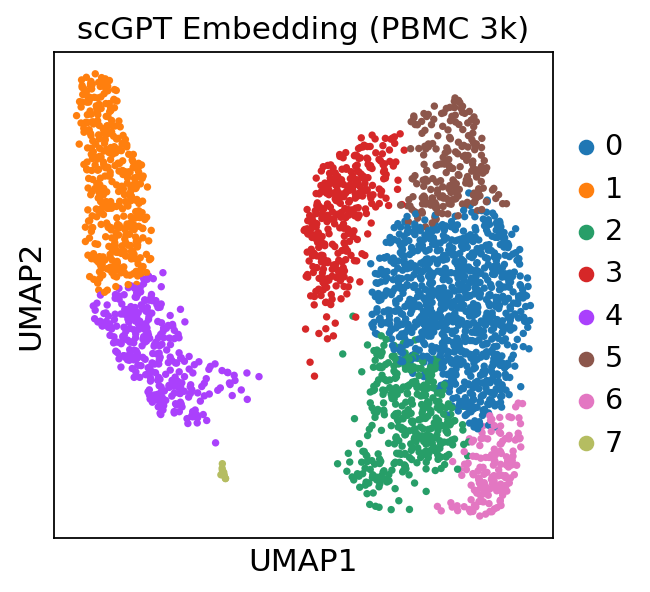

In [14]:
# Load results and visualize
adata_scgpt = sc.read_h5ad("pbmc3k_scgpt.h5ad")
print(f"Embedding key: X_scGPT")
print(f"Embedding shape: {adata_scgpt.obsm['X_scGPT'].shape}")

# Compute UMAP from scGPT embeddings
sc.pp.neighbors(adata_scgpt, use_rep='X_scGPT')
sc.tl.umap(adata_scgpt)

# Cluster for visualization
sc.tl.leiden(adata_scgpt, resolution=0.5)
sc.pl.umap(adata_scgpt, color=['leiden'], title='scGPT Embedding (PBMC 3k)')

### 5b. Using the low-level `ov.llm.SCLLMManager` API

For more fine-grained control (fine-tuning, cell type annotation, custom preprocessing), you can use the model-specific `SCLLMManager` interface directly.

In [15]:
# Low-level API: direct model access via ov.llm.SCLLMManager
# This gives you finer-grained control over the model pipeline.
#
# manager = ov.llm.SCLLMManager(
#     model_type="scgpt",
#     model_path="path/to/scgpt/checkpoint",
# )
#
# # Get embeddings with full control
# adata = sc.read_h5ad("pbmc3k.h5ad")
# embeddings = manager.get_embeddings(adata, batch_size=64)
# adata.obsm['X_scGPT'] = embeddings
#
# # Fine-tune on reference data
# ref_adata = adata[adata.obs['celltype'].isin(['CD4 T', 'CD8 T', 'B'])]
# manager.fine_tune(train_adata=ref_adata, task="annotation", epochs=5)
#
# # Predict cell types
# predictions = manager.predict_celltypes(adata)

print("See ov.llm.SCLLMManager documentation for low-level API usage.")

See ov.llm.SCLLMManager documentation for low-level API usage.


## Step 6: Interpret Results

`ov.fm.interpret_results()` generates QA metrics for model outputs, including embedding dimensionality, silhouette scores, and provenance tracking.

In [16]:
# Interpret results from the scGPT run
interpretation = ov.fm.interpret_results(
    "pbmc3k_scgpt.h5ad",
    task="embed",
)

print("=== QA Metrics ===")
print(f"Cells: {interpretation['metrics']['n_cells']:,}")
print(f"Genes: {interpretation['metrics']['n_genes']:,}")

if 'embeddings' in interpretation['metrics']:
    for key, info in interpretation['metrics']['embeddings'].items():
        print(f"\nEmbedding '{key}':")
        print(f"  Dimensions: {info['dim']}")
        print(f"  Cells: {info['n_cells']}")
        if 'silhouette' in info:
            print(f"  Silhouette score: {info['silhouette']:.4f}")

if 'provenance' in interpretation['metrics']:
    print(f"\nProvenance: {interpretation['metrics']['provenance']}")

=== QA Metrics ===
Cells: 2,700
Genes: 12,300

Embedding 'X_scGPT':
  Dimensions: 512
  Cells: 2700


## Multi-Model Comparison

One of the key strengths of `ov.fm` is the ability to run multiple models on the same dataset and compare results. The example below demonstrates this with models that have adapters installed. Models that are not installed will return a graceful error message instead of crashing.

> **Note:** Each model requires its own dependencies and checkpoints. Install models following their respective documentation before running.

In [17]:
# Run multiple models on the same dataset
# Only models with installed adapters will succeed; others return graceful errors
models_to_run = ["scgpt", "geneformer", "uce"]
results = {}

for model_name in models_to_run:
    print(f"\n{'='*50}")
    print(f"Running {model_name}...")
    result = ov.fm.run(
        task="embed",
        model_name=model_name,
        adata_path="pbmc3k.h5ad",
        output_path=f"pbmc3k_{model_name}.h5ad",
        device="auto",
    )
    results[model_name] = result
    if 'error' in result:
        print(f"  Status: {result['error']}")
    else:
        print(f"  Status: {result.get('status', 'unknown')}")
        print(f"  Output: {result.get('output_keys', [])}")


Running scgpt...


[Loaded] Loaded vocabulary: 60,697 genes
[Loaded] Loaded model config from args.json
[ℹ️Info] Key Parameters Model Information:
    embsize: 512
    nheads: 8
    d_hid: 512
    nlayers: 12
    n_layers_cls: 3


[Preprocessing] Analyzing model checkpoint for n_cls inference...
[Warning] No classifier layers found in checkpoint
[ℹ️Info] Using default n_cls=50


[Warning] Loading compatible weights only


[Loaded] Compatible weights loaded: 135/163
[Warning] Some weights incompatible (28)
[ℹ️Info] Model classes: 50
[Loaded] Model ready on cuda
[Preprocessing] Filtering genes by vocabulary
[ℹ️Info] Matched 12300/13714 genes
[Loaded] Retained 12300 genes
[Loaded] Preprocessor initialized
    n_bins: 51, normalize: 10000.0
[ℹ️Info] Data inspection - Mean: 2279.3, Range: [0.000, 419.000]
    [ℹ️Info] Auto-detected: raw counts
    [Loaded] Decision: applying normalization
    [Loaded] Will apply normalization
[Preprocessing] Applying preprocessing pipeline
Normalizing total counts ...


...

[Embedding] Processing data in memory


[Embedding] UCE model loaded and ready for inference


[Embedding] Creating UCE dataset in memory


UCE inference:   0%|          | 0/108 [00:00<?, ?it/s]

[Embedding] Extracted embeddings: (2700, 1280)
  Status: success
  Output: ['X_uce']


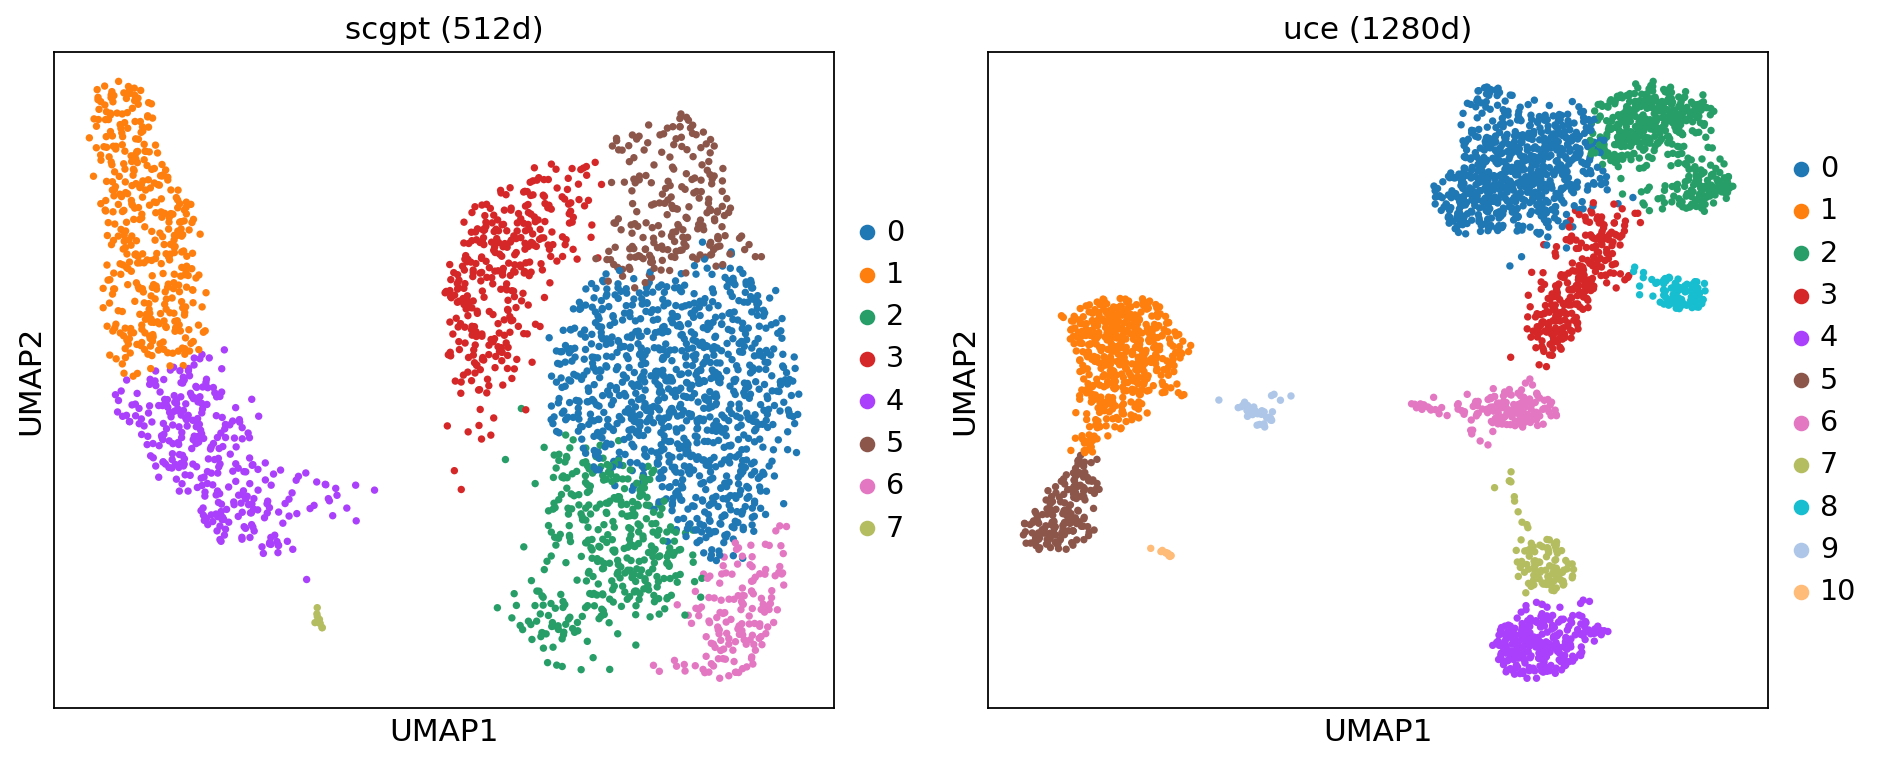

In [18]:
# Compare embeddings visually (only for successfully run models)
import matplotlib.pyplot as plt
import os

successful_models = [m for m in models_to_run if os.path.exists(f"pbmc3k_{m}.h5ad") and 'error' not in results.get(m, {})]

if successful_models:
    fig, axes = plt.subplots(1, len(successful_models), figsize=(6*len(successful_models), 5))
    if len(successful_models) == 1:
        axes = [axes]

    for i, model_name in enumerate(successful_models):
        adata_m = sc.read_h5ad(f"pbmc3k_{model_name}.h5ad")
        info = ov.fm.describe_model(model_name)
        emb_key = info['output_contract']['embedding_key'].split("'")[1]
        
        sc.pp.neighbors(adata_m, use_rep=emb_key)
        sc.tl.umap(adata_m)
        sc.tl.leiden(adata_m, resolution=0.5)
        sc.pl.umap(adata_m, color='leiden', ax=axes[i], 
                   title=f"{model_name} ({adata_m.obsm[emb_key].shape[1]}d)",
                   show=False)

    plt.tight_layout()
    plt.show()
else:
    print("No models completed successfully for comparison.")

In [19]:
# Quantitative comparison: silhouette scores
from sklearn.metrics import silhouette_score

comparison_results = []
for model_name in successful_models:
    adata_m = sc.read_h5ad(f"pbmc3k_{model_name}.h5ad")
    info = ov.fm.describe_model(model_name)
    emb_key = info['output_contract']['embedding_key'].split("'")[1]
    emb = adata_m.obsm[emb_key]
    
    # Use leiden clusters for silhouette score
    if 'leiden' not in adata_m.obs:
        sc.pp.neighbors(adata_m, use_rep=emb_key)
        sc.tl.leiden(adata_m, resolution=0.5)
    
    sil = silhouette_score(emb, adata_m.obs['leiden'])
    comparison_results.append({
        'Model': model_name,
        'Embedding Dim': emb.shape[1],
        'Silhouette Score': round(sil, 4),
    })

pd.DataFrame(comparison_results)

,Model,Embedding Dim,Silhouette Score
0,scgpt,512,0.1540
1,uce,1280,0.1691


## Advanced: Custom Checkpoint Paths

By default, `ov.fm` looks for checkpoints in `~/.cache/omicverse/models/<model_name>/`. You can override this via:
- The `checkpoint_dir` parameter in `ov.fm.run()`
- Environment variables: `OV_FM_CHECKPOINT_DIR_SCGPT`, `OV_FM_CHECKPOINT_DIR_GENEFORMER`, etc.
- A global base directory: `OV_FM_CHECKPOINT_DIR` with model-named subfolders

In [20]:
# Using a custom checkpoint directory (example - adjust path for your setup)
# result = ov.fm.run(
#     task="embed",
#     model_name="scgpt",
#     adata_path="pbmc3k.h5ad",
#     output_path="pbmc3k_scgpt_custom.h5ad",
#     checkpoint_dir="/path/to/my/scgpt/checkpoint",
# )
print("Adjust checkpoint_dir to your local path before running.")

Adjust checkpoint_dir to your local path before running.


## Advanced: Conda Subprocess Isolation

Some models have conflicting dependencies. `ov.fm` supports running models in isolated conda environments via subprocess. If a conda env named `scfm-<model_name>` exists (e.g., `scfm-scgpt`), `ov.fm.run()` will automatically use it.

```bash
# Create an isolated environment for a model
conda create -n scfm-scgpt python=3.10
conda activate scfm-scgpt
pip install omicverse scgpt
```

To disable conda subprocess execution:
```python
import os
os.environ['OV_FM_DISABLE_CONDA_SUBPROCESS'] = '1'
```

## Advanced: Plugin System

You can register custom models with `ov.fm` via the plugin system.

### Entry-point plugins (pip packages)

In your package's `pyproject.toml`:
```toml
[project.entry-points."omicverse.fm"]
my_model = "my_package.fm_plugin:register"
```

### Local plugins

Place a Python file in `~/.omicverse/plugins/fm/`:

In [21]:
# Example: registering a custom model plugin
from omicverse.fm.registry import ModelSpec, TaskType, Modality, SkillReadyStatus, OutputKeys

# Define model spec
my_spec = ModelSpec(
    name="my_custom_model",
    version="v1.0",
    skill_ready=SkillReadyStatus.READY,
    tasks=[TaskType.EMBED],
    modalities=[Modality.RNA],
    species=["human"],
    output_keys=OutputKeys(embedding_key="X_my_model"),
    embedding_dim=256,
)

# Register it
registry = ov.fm.get_registry()
registry.register(my_spec, source="user")

# Now it appears in list_models
custom = [m['name'] for m in ov.fm.list_models()['models'] if 'custom' in m['name']]
print(f"Registered custom models: {custom}")

Registered custom models: ['my_custom_model']


## Model Quick Reference

| Model | Dim | Gene IDs | Species | Key Strength |
|-------|-----|----------|---------|-------------|
| **scGPT** | 512 | Symbol | human, mouse | Multi-modal (RNA+ATAC+Spatial), attention maps |
| **Geneformer** | 512 | Ensembl | human | CPU-capable, rank-value encoding, network biology |
| **UCE** | 1280 | Symbol | 7 species | Broadest species support, protein structure embeddings |
| **scFoundation** | 512 | Custom | human | Perturbation/drug response, xTrimoGene architecture |
| **CellPLM** | 512 | Symbol | human | Fastest inference, cell-centric (not gene-centric) |
| **scBERT** | 200 | Symbol | human | Lightest model, 200-dim compact embeddings |
| **Nicheformer** | 512 | Symbol | human, mouse | Spatial-aware, niche modeling |
| **scMulan** | 512 | Symbol | human | Native multi-omics (RNA+ATAC+Protein) |

For the full list of 22 models, run `ov.fm.list_models()`.

## API Reference Summary

| Function | Purpose |
|----------|--------|
| `ov.fm.list_models(task=)` | Browse available models, filter by task |
| `ov.fm.describe_model(name)` | Get full model spec and I/O contract |
| `ov.fm.profile_data(path)` | Auto-detect species, gene scheme, modality |
| `ov.fm.select_model(path, task=)` | Recommend best model for your data |
| `ov.fm.preprocess_validate(path, model, task)` | Check compatibility, get fix suggestions |
| `ov.fm.run(task=, model_name=, adata_path=)` | Execute inference |
| `ov.fm.interpret_results(path, task=)` | Generate QA metrics and visualizations |